## **Load Libraries**

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import TfidfVectorizer

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Download components
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## **Load Data**

In [25]:
sales = pd.read_csv("/content/drive/MyDrive/CIND 820/Milestone 4/sales_compressed.csv")

## **Train-Test Split**

In [26]:
X = sales[['actual_price', 'discounted_price', 'discount_percentage', 'rating_count', 'rating']] # Predictors
y = sales['category'] # Target
# 80% of the data is for training, 20% is for testing
# Stratify=y maintains proportions in target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Treatment of Outliers**

In [27]:
# Temporarily combine X_train and y_train
X_train["category"] = y_train

numerical_features = ['actual_price', 'discounted_price', 'discount_percentage', 'rating_count', 'rating']

for feature in numerical_features:
      # Calculate the IQR and mean for every featrure by category
      category_stats = X_train.groupby("category")[feature].agg(
          q1=lambda x: x.quantile(0.25),
          q3=lambda x: x.quantile(0.75),
          iqr=(lambda x: x.quantile(0.75) - x.quantile(0.25)),
          mean='mean'
      )
      category_stats['min_val'] = category_stats['q1'] - 1.5 * category_stats['iqr']
      category_stats['max_val'] = category_stats['q3'] + 1.5 * category_stats['iqr']

      categories_train = y_train
      categories_test = y_test

      # Map category stats to each row of the data
      cat_min_vals_train = categories_train.map(category_stats['min_val'])
      cat_max_vals_train = categories_train.map(category_stats['max_val'])
      cat_mean_vals_train = categories_train.map(category_stats['mean'])

      cat_min_vals_test = categories_test.map(category_stats['min_val'])
      cat_max_vals_test = categories_test.map(category_stats['max_val'])
      cat_mean_vals_test = categories_test.map(category_stats['mean'])

      # Create a boolean mask to detect outliers
      # Compare each row's feature value to the corresponding min/max for its category
      outliers_train = (X_train[feature] < cat_min_vals_train) | (X_train[feature] > cat_max_vals_train)
      outliers_test = (X_test[feature] < cat_min_vals_test) | (X_test[feature] > cat_max_vals_test)

      # Replace outliers using category mean where boolean mask is true
      X_train[feature] = np.where(outliers_train, cat_mean_vals_train, X_train[feature])
      X_test[feature] = np.where(outliers_test, cat_mean_vals_test, X_test[feature])

X_train = X_train.drop(columns=["category"])

## **Multinomial Logistic Regression**

In [28]:
# Normalize the numerical data
scaler = StandardScaler()
X_train_regression = scaler.fit_transform(X_train)
X_test_regression = scaler.fit_transform(X_test)

# Build model
reg_model = LogisticRegression(max_iter=200)
reg_model.fit(X_train_regression, y_train.to_numpy())

LogisticRegression(max_iter=200)

In [29]:
# Check for linear relationships between log-odds of the predictors and target using Box-Tidwell test
bt_test_data = pd.DataFrame(data=X_train, columns=["actual_price", "discounted_price", "discount_percentage", "rating_count", "rating"])

# Scale the data to prevent NaN p-values in the model
# Use min-max scaling instead of normalization to ensure positive values for the log function
scaler = MinMaxScaler(feature_range=(1, 10))
bt_test_data = pd.DataFrame(scaler.fit_transform(bt_test_data),
    columns=["actual_price", "discounted_price", "discount_percentage", "rating_count", "rating"])

# Add interactions between numerical predictors and their log equivalents
for col in ["actual_price", "discounted_price", "discount_percentage", "rating_count", "rating"]:
    bt_test_data[f"{col}_log"] = bt_test_data[col] * np.log(bt_test_data[col])

# Add target column
bt_test_data["category"] = y_train

# The implementation of the model requires the target to be label encoded
labeler = LabelEncoder()
bt_test_data["category"] = labeler.fit_transform(bt_test_data["category"])

# Build models to test the significance of each interaction separately
numerical_features = ["actual_price", "discounted_price", "discount_percentage", "rating_count", "rating"]
interactions = ["actual_price_log", "discounted_price_log", "discount_percentage_log", "rating_count_log", "rating_log"]

for feature_index in range(len(numerical_features)):
  bt_model = smf.mnlogit(f"category ~ {numerical_features[feature_index]} + {interactions[feature_index]}", data=bt_test_data).fit()
  # P-value of interaction coefficient should be greater than 0.05 for linearity
  print(bt_model.pvalues.loc[interactions[feature_index]])


Optimization terminated successfully.
         Current function value: 1.703858
         Iterations 7
0    0.902643
1    0.398525
2    0.290396
3    0.312356
4    0.951060
5    0.393115
Name: actual_price_log, dtype: float64
Optimization terminated successfully.
         Current function value: 1.702711
         Iterations 8
0    0.545898
1    0.250998
2    0.845499
3    0.415203
4    0.815493
5    0.317644
Name: discounted_price_log, dtype: float64
Optimization terminated successfully.
         Current function value: 1.697414
         Iterations 8
0    0.786968
1    0.882458
2    0.232719
3    0.284362
4    0.580592
5    0.325268
Name: discount_percentage_log, dtype: float64
Optimization terminated successfully.
         Current function value: 1.684295
         Iterations 10
0    0.874236
1    0.206716
2    0.926556
3    0.653377
4    0.419604
5    0.145834
Name: rating_count_log, dtype: float64
Optimization terminated successfully.
         Current function value: 1.698774
        

In [30]:
# Remove one of the price variables to address multicolinearity
vif_data = sm.add_constant(sales[['actual_price', 'discount_percentage', 'rating_count', 'rating']]) # Add constant column for calculation
vif_values = pd.DataFrame()
vif_values["Feature"] = vif_data.columns
vif_values["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

# Exclude column of constant values
vif_values[vif_values['Feature'] != "const"]

,Feature,VIF
1,actual_price,1.253017
2,discount_percentage,1.213865
3,rating_count,1.025655
4,rating,1.092751


In [31]:
# Oorder of categories in the model
reg_model.classes_

array(['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
       'Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear',
       'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
       'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
       'Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones',
       'Electronics|WearableTechnology|SmartWatches'], dtype=object)

In [32]:
# Model coefficients
coefficients = pd.DataFrame(reg_model.coef_, columns=['actual_price', 'discounted_price', 'discount_percentage', 'rating_count', 'rating'])
coefficients.index = ['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']
coefficients

,actual_price,discounted_price,discount_percentage,rating_count,rating
Cables|USBCables,-3.778993,-1.993861,0.542352,-0.399315,0.823296
Headphones|In-Ear,-0.716802,-0.338810,0.460671,2.167929,-1.051029
Accessories|RemoteControls,-1.900018,-1.152788,0.303394,-2.590959,-0.595508
Televisions|SmartTelevisions,2.860498,1.875400,0.171509,0.018963,1.282237
Smartphones&BasicMobiles|Smartphones,1.336836,1.801814,-2.663547,0.219221,-0.293385
WearableTechnology|SmartWatches,2.198480,-0.191755,1.185621,0.584161,-0.165610


In [33]:
# Model evaluation

y_pred = reg_model.predict(X_test_regression) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.76      0.91      0.83        32
                   Headphones|In-Ear       0.67      0.60      0.63        10
          Accessories|RemoteControls       0.56      0.50      0.53        10
        Televisions|SmartTelevisions       0.85      0.92      0.88        12
Smartphones&BasicMobiles|Smartphones       0.92      0.86      0.89        14
     WearableTechnology|SmartWatches       0.88      0.58      0.70        12

                            accuracy                           0.78        90
                           macro avg       0.77      0.73      0.74        90
                        weighted avg       0.78      0.78      0.77        90



## **KNN**

In [34]:
# Apply min-max scaling to the numerical features
scaler = MinMaxScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.fit_transform(X_test)

# Train the model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_knn, y_train.to_numpy())

KNeighborsClassifier()

In [35]:
# Model evaluation

y_pred = knn_model.predict(X_test_knn) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.79      0.84      0.82        32
                   Headphones|In-Ear       0.67      0.60      0.63        10
          Accessories|RemoteControls       0.43      0.60      0.50        10
        Televisions|SmartTelevisions       0.92      0.92      0.92        12
Smartphones&BasicMobiles|Smartphones       0.93      0.93      0.93        14
     WearableTechnology|SmartWatches       1.00      0.58      0.74        12

                            accuracy                           0.78        90
                           macro avg       0.79      0.75      0.76        90
                        weighted avg       0.80      0.78      0.78        90



## **Decision Tree**

In [36]:
# Build model
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train.to_numpy())

DecisionTreeClassifier(max_depth=5)

In [37]:
# Model evaluation

y_pred = tree_model.predict(X_test) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.78      0.91      0.84        32
                   Headphones|In-Ear       0.82      0.90      0.86        10
          Accessories|RemoteControls       0.50      0.40      0.44        10
        Televisions|SmartTelevisions       0.85      0.92      0.88        12
Smartphones&BasicMobiles|Smartphones       0.92      0.86      0.89        14
     WearableTechnology|SmartWatches       1.00      0.67      0.80        12

                            accuracy                           0.81        90
                           macro avg       0.81      0.77      0.79        90
                        weighted avg       0.81      0.81      0.81        90



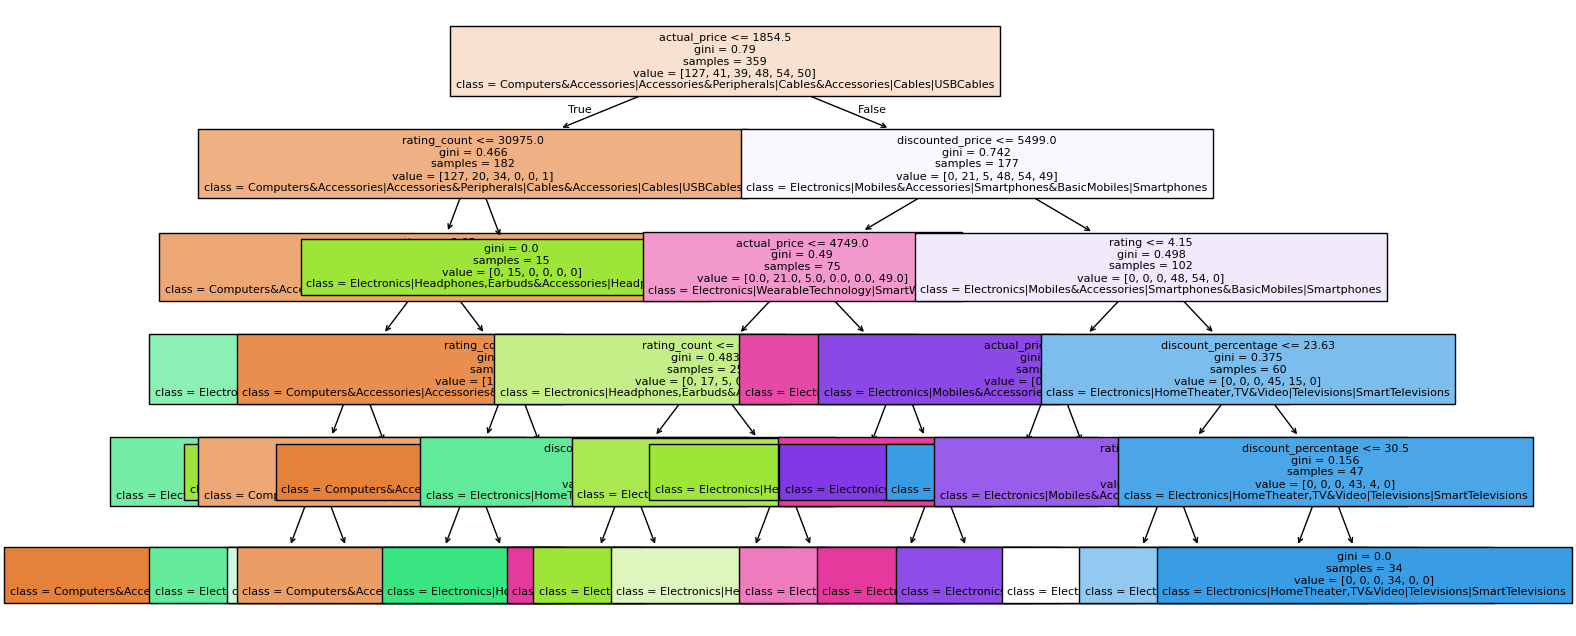

In [38]:
# Visualize the tree
plt.figure(figsize=(15, 8))
plot_tree(tree_model,
          filled=True,
          fontsize=8,
          feature_names=list(X_train.columns),
          class_names=['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
       'Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear',
       'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
       'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
       'Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones',
       'Electronics|WearableTechnology|SmartWatches'])
plt.show()

## **Information Retrieval Pipeline**

In [39]:
# Filter data to include product descriptions and category
products = sales[["category", "about_product"]]
products['id'] = [f'Doc{i+1:02d}' for i in range(len(products))]
products.head()

,category,about_product,id
0,Computers&Accessories|Accessories&Peripherals|...,High Compatibility : Compatible With iPhone 12...,Doc01
1,Computers&Accessories|Accessories&Peripherals|...,"Compatible with all Type C enabled devices, be...",Doc02
2,Computers&Accessories|Accessories&Peripherals|...,【 Fast Charger& Data Sync】-With built-in safet...,Doc03
3,Computers&Accessories|Accessories&Peripherals|...,The boAt Deuce USB 300 2 in 1 cable is compati...,Doc04
4,Computers&Accessories|Accessories&Peripherals|...,[CHARGE & SYNC FUNCTION]- This cable comes wit...,Doc05


In [40]:
# Apply text pre-processing

# Initialize resources
stop_en = set(stopwords.words('english'))
lemm = WordNetLemmatizer()
stemmer = PorterStemmer()

def text_processing(text: str) -> str:
    text = str(text).lower()                                 # Lowercasing
    text = re.sub(r'\d+', ' num ', text)                     # Replace digits with the string 'num'
    tokens = word_tokenize(text)                             # Tokenization
    tokens = [t for t in tokens if t.isalpha()]              # Remove non-alphabetic tokens
    tokens = [t for t in tokens if t not in stop_en]         # Stopword removal
    tokens = [lemm.lemmatize(t) for t in tokens]             # Lemmatization
    tokens = [stemmer.stem(t) for t in tokens]               # Stemming
    return ' '.join(tokens)

# Pre-process each of the product descriptions
products['clean_about_product'] = products['about_product'].astype(str).apply(text_processing)
products[['id', 'clean_about_product']].head()

,id,clean_about_product
0,Doc01,high compat compat iphon num num iphon num num...
1,Doc02,compat type c enabl devic android smartphon mi...
2,Doc03,fast charger data safeti proctect copper wire ...
3,Doc04,boat deuc usb num num num cabl compat smartpho...
4,Doc05,charg sync function cabl come charg data sync ...


In [41]:
# Unigram TF-IDF
tfidf_uni = TfidfVectorizer(ngram_range=(1,1), min_df=5, norm='l2')
X_uni_tfidf = tfidf_uni.fit_transform(products['clean_about_product'])

# Dimensions of matrix (rows = documents, columns = terms)
X_uni_tfidf.shape

(449, 957)

In [42]:
# Model evaluation

# Compute cosine similarity between all documents and extract scores for the Doc401
similarities = cosine_similarity(X_uni_tfidf, X_uni_tfidf)[300]

# Find the top similar products to Doc401
ranked_indices = np.argsort(similarities)[::-1] # Reverse the indices to rank from largest to smallest
similar_products = [(products['id'].iloc[i], products['category'].iloc[i], products['about_product'].iloc[i], float(similarities[i])) for i in ranked_indices][:5]
pd.DataFrame(similar_products, columns=["ID", "Category", "Description", "Cosine Similarity"])

,ID,Category,Description,Cosine Similarity
0,Doc301,Electronics|Mobiles&Accessories|Smartphones&Ba...,Processor: Octa-core MediaTek Helio G96 gaming...,1.000000
1,Doc396,Electronics|Mobiles&Accessories|Smartphones&Ba...,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB ...,0.755079
2,Doc361,Electronics|Mobiles&Accessories|Smartphones&Ba...,Segment Best 16.21 centimeters (6.4-inch) Supe...,0.754045
3,Doc370,Electronics|Mobiles&Accessories|Smartphones&Ba...,Processor: MediaTek Dimensity 810 Octa-core 5G...,0.750661
4,Doc385,Electronics|Mobiles&Accessories|Smartphones&Ba...,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB|...,0.747644


## **Convert to HTML**

In [43]:
!pip install nbconvert

In [44]:
!jupyter nbconvert --to html "/content/drive/MyDrive/CIND 820/Milestone 4/Baseline_Model_Development_Evaluation.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/CIND 820/Milestone 4/Baseline_Model_Development_Evaluation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 648211 bytes to /content/drive/MyDrive/CIND 820/Milestone 4/Baseline_Model_Development_Evaluation.html
